## Deep Learning y Sistemas Inteligentes - Laboratorio 7
- Josue Marroquin 22397
- Sebastian Huertas 22295

Referencias:
- Box2D -> https://pypi.org/project/Box2D/
- Cart Pole -> https://gymnasium.farama.org/environments/classic_control/cart_pole/

### 1) Liberias

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt

### 2) Entorno

In [2]:
import gymnasium as gym
import numpy as np

# Crear el entorno CartPole-v1
env = gym.make("CartPole-v1")

# Información del entorno
print("Action Space:", env.action_space)
print("Observation Space:", env.observation_space)
print("Observation Space Shape:", env.observation_space.shape)
print("Observation Space High:", env.observation_space.high)
print("Observation Space Low:", env.observation_space.low)


Action Space: Discrete(2)
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Observation Space Shape: (4,)
Observation Space High: [4.8               inf 0.41887903        inf]
Observation Space Low: [-4.8               -inf -0.41887903        -inf]


### 3) Redes en linea y de destino

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [4]:
class DQN(nn.Module):
    """Red neuronal para DQN"""
    def __init__(self, state_size=4, action_size=2, hidden_size=128):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Crear las redes
state_size = env.observation_space.shape[0]  # 4 (posición cart, velocidad cart, ángulo pole, velocidad angular pole)
action_size = env.action_space.n  # 2 (izquierda, derecha)

# Red en línea (online network) - se actualiza frecuentemente
q_network = DQN(state_size, action_size).to(device)

# Red de destino (target network) - se actualiza periódicamente
target_network = DQN(state_size, action_size).to(device)

# Inicializar la red de destino con los mismos pesos que la red en línea
target_network.load_state_dict(q_network.state_dict())

# Optimizador solo para la red en línea
optimizer = optim.Adam(q_network.parameters(), lr=0.001)

print("Redes creadas:")
print(f"Red en línea: {q_network}")
print(f"Red de destino: {target_network}")
print(f"Parámetros de la red: {sum(p.numel() for p in q_network.parameters())}")

Redes creadas:
Red en línea: DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)
Red de destino: DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)
Parámetros de la red: 17410


### 4) Establecer Hiperparametros

In [5]:
NUM_EPISODES = 1000          # Número de episodios de entrenamiento
MAX_STEPS = 500              # Máximo número de pasos por episodio
BATCH_SIZE = 32              # Tamaño del batch para el entrenamiento
LEARNING_RATE = 0.001        # Tasa de aprendizaje (ya definida en optimizer)

# Parámetros del algoritmo DQN
GAMMA = 0.99                 # Factor de descuento (discount factor)
TARGET_UPDATE = 10           # Frecuencia de actualización de la red objetivo (cada 10 episodios)

# Parámetros de exploración (epsilon-greedy)
EPSILON_START = 1.0          # Epsilon inicial (100% exploración)
EPSILON_END = 0.01           # Epsilon mínimo (1% exploración)
EPSILON_DECAY = 0.995        # Factor de decaimiento del epsilon

# Parámetros del Experience Replay Buffer
BUFFER_SIZE = 10000          # Tamaño del buffer de experiencias
MIN_BUFFER_SIZE = 1000       # Tamaño mínimo del buffer antes de entrenar

# Variables de estado
epsilon = EPSILON_START      # Epsilon actual
episode_rewards = []         # Lista para almacenar recompensas por episodio
episode_lengths = []         # Lista para almacenar longitud de episodios

In [6]:
# Función para calcular epsilon con decaimiento
def get_epsilon(episode):
    """Calcula el valor de epsilon para un episodio dado"""
    return max(EPSILON_END, EPSILON_START * (EPSILON_DECAY ** episode))

# Función para mostrar progreso del entrenamiento
def print_training_progress(episode, epsilon, reward, avg_reward):
    """Imprime el progreso del entrenamiento"""
    if episode % 100 == 0 or episode < 10:
        print(f"Episodio {episode:4d} | Epsilon: {epsilon:.3f} | Recompensa: {reward:3.0f} | Promedio: {avg_reward:.2f}")

# Función para evaluar el rendimiento
def evaluate_agent(num_episodes=10):
    """Evalúa el agente sin exploración (epsilon=0)"""
    total_reward = 0
    for _ in range(num_episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            # Selección de acción sin exploración
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = q_network(state_tensor)
                action = q_values.argmax().item()
            
            state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            done = terminated or truncated
        
        total_reward += episode_reward
    
    return total_reward / num_episodes

### 5) Seleccion de acciones epsilon-greedy

In [7]:
def select_action(state, epsilon):
    """
    Selecciona una acción usando la política epsilon-greedy
    
    Args:
        state: Estado actual del entorno
        epsilon: Probabilidad de exploración (0-1)
    
    Returns:
        action: Acción seleccionada (0 o 1)
    """
    if random.random() < epsilon:
        # Exploración: seleccionar acción aleatoria
        return env.action_space.sample()
    else:
        # Explotación: seleccionar la mejor acción según Q-network
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = q_network(state_tensor)
            return q_values.argmax().item()

def update_target_network():
    """
    Actualiza la red de destino copiando los pesos de la red en línea
    """
    target_network.load_state_dict(q_network.state_dict())

# Probar la función de selección de acciones
print("Probando selección de acciones epsilon-greedy:")
test_state, _ = env.reset()
print(f"Estado de prueba: {test_state}")

# Probar con diferentes valores de epsilon
epsilons = [1.0, 0.5, 0.1, 0.0]
for eps in epsilons:
    actions = []
    for _ in range(10):
        action = select_action(test_state, eps)
        actions.append(action)
    
    exploration_rate = sum(actions) / len(actions) if len(actions) > 0 else 0
    print(f"Epsilon {eps:.1f}: Acciones = {actions[:5]}... (Tasa exploración aprox: {exploration_rate:.2f})")

Probando selección de acciones epsilon-greedy:
Estado de prueba: [0.04034908 0.0458531  0.04871979 0.04968619]
Epsilon 1.0: Acciones = [np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1)]... (Tasa exploración aprox: 0.40)
Epsilon 0.5: Acciones = [np.int64(0), 1, 1, np.int64(0), 1]... (Tasa exploración aprox: 0.70)
Epsilon 0.1: Acciones = [1, 1, 1, 1, 1]... (Tasa exploración aprox: 0.90)
Epsilon 0.0: Acciones = [1, 1, 1, 1, 1]... (Tasa exploración aprox: 1.00)


### 6) Reproducción de la experiencia 

In [8]:
class ReplayBuffer:
    """
    Buffer circular para almacenar experiencias del agente
    """
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """
        Añade una experiencia al buffer
        
        Args:
            state: Estado actual
            action: Acción tomada
            reward: Recompensa recibida
            next_state: Siguiente estado
            done: Si el episodio terminó
        """
        self.buffer.append((state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        """
        Muestrea un batch aleatorio de experiencias
        
        Args:
            batch_size: Tamaño del batch a muestrear
        
        Returns:
            Tuple de tensores (states, actions, rewards, next_states, dones)
        """
        batch = random.sample(self.buffer, batch_size)
        
        # Separar los componentes del batch
        states = torch.FloatTensor([e[0] for e in batch]).to(device)
        actions = torch.LongTensor([e[1] for e in batch]).to(device)
        rewards = torch.FloatTensor([e[2] for e in batch]).to(device)
        next_states = torch.FloatTensor([e[3] for e in batch]).to(device)
        dones = torch.BoolTensor([e[4] for e in batch]).to(device)
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

# Crear el buffer de experiencias
replay_buffer = ReplayBuffer(BUFFER_SIZE)

print(f"Buffer de experiencias creado con capacidad: {BUFFER_SIZE}")
print(f"Tamaño mínimo antes de entrenar: {MIN_BUFFER_SIZE}")

Buffer de experiencias creado con capacidad: 10000
Tamaño mínimo antes de entrenar: 1000


### 7/8) Ciclo de entrenamiento y visualización

In [9]:
def train_dqn():
    """
    Entrena la red DQN usando experience replay
    """
    if len(replay_buffer) < MIN_BUFFER_SIZE:
        return None
    
    # Muestrear batch del buffer
    states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
    
    # Calcular Q-values actuales
    current_q_values = q_network(states).gather(1, actions.unsqueeze(1))
    
    # Calcular Q-values objetivo usando la red de destino
    with torch.no_grad():
        next_q_values = target_network(next_states).max(1)[0]
        target_q_values = rewards + (GAMMA * next_q_values * ~dones)
    
    # Calcular pérdida
    loss = nn.MSELoss()(current_q_values.squeeze(), target_q_values)
    
    # Actualizar la red
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

# Función principal de entrenamiento
def train_agent(render=0):
    """
    Ciclo principal de entrenamiento del agente DQN
    
    Args:
        render: 1 para renderizar (con visualización), 0 para no renderizar (más rápido)
    """
    episode_rewards = []
    episode_losses = []
    
    # Crear entorno apropiado según el parámetro render
    if render == 1:
        env_training = gym.make("CartPole-v1", render_mode="human")
        print("Iniciando entrenamiento DQN con visualización...")
    else:
        env_training = env  # Usar el entorno sin renderizado
        print("Iniciando entrenamiento DQN...")
    
    print("=" * 60)
    
    for episode in range(NUM_EPISODES):
        # Resetear el entorno
        state, _ = env_training.reset()
        episode_reward = 0
        episode_loss = []
        
        # Calcular epsilon para este episodio
        current_epsilon = get_epsilon(episode)
        
        for step in range(MAX_STEPS):
            # Seleccionar acción usando epsilon-greedy
            action = select_action(state, current_epsilon)
            
            # Ejecutar acción en el entorno
            next_state, reward, terminated, truncated, _ = env_training.step(action)
            done = terminated or truncated
            
            # Almacenar experiencia en el buffer
            replay_buffer.push(state, action, reward, next_state, done)
            
            # Entrenar la red si hay suficientes experiencias
            loss = train_dqn()
            if loss is not None:
                episode_loss.append(loss)
            
            # Actualizar estado y recompensa acumulada
            state = next_state
            episode_reward += reward
            
            # Si el episodio terminó, salir del loop
            if done:
                break
        
        # Actualizar la red de destino cada TARGET_UPDATE episodios
        if episode % TARGET_UPDATE == 0:
            update_target_network()
            print(f"Red de destino actualizada en episodio {episode}")
        
        # Registrar métricas del episodio
        episode_rewards.append(episode_reward)
        avg_loss = np.mean(episode_loss) if episode_loss else 0
        episode_losses.append(avg_loss)
        
        # Mostrar progreso
        if len(episode_rewards) >= 100:
            avg_reward = np.mean(episode_rewards[-100:])
        else:
            avg_reward = np.mean(episode_rewards)
        
        print_training_progress(episode, current_epsilon, episode_reward, avg_reward)
        
        # Evaluación periódica
        if episode % 200 == 0 and episode > 0:
            eval_reward = evaluate_agent(10)
            print(f"Evaluación episodio {episode}: Recompensa promedio = {eval_reward:.2f}")
        
        # Criterio de parada temprana (opcional)
        if len(episode_rewards) >= 100 and avg_reward >= 475:
            print(f"\n¡Problema resuelto en episodio {episode}!")
            print(f"Recompensa promedio últimos 100 episodios: {avg_reward:.2f}")
            break
    
    # Cerrar entorno de entrenamiento si se creó uno específico
    if render == 1:
        env_training.close()
    
    print("\nEntrenamiento completado!")
    return episode_rewards, episode_losses

In [11]:
# Ejecucion del entrenamiento

print("¡Iniciando entrenamiento del agente DQN!")
print(f"Configuración:")
print(f"- Episodios: {NUM_EPISODES}")
print(f"- Epsilon inicial: {EPSILON_START}")
print(f"- Epsilon final: {EPSILON_END}")
print(f"- Actualización de red objetivo cada: {TARGET_UPDATE} episodios")
print(f"- Tamaño del buffer: {BUFFER_SIZE}")

# Ejecutar entrenamiento
rewards, losses = train_agent(render=0) # Cambiar a 1 para ver la visualización, notar que con render tarda más

print(f"\nResultados del entrenamiento:")
print(f"- Episodios completados: {len(rewards)}")
print(f"- Recompensa promedio últimos 100 episodios: {np.mean(rewards[-100:]):.2f}")
print(f"- Recompensa máxima: {max(rewards):.2f}")
print(f"- Pérdida promedio: {np.mean([l for l in losses if l > 0]):.4f}")

¡Iniciando entrenamiento del agente DQN!
Configuración:
- Episodios: 1000
- Epsilon inicial: 1.0
- Epsilon final: 0.01
- Actualización de red objetivo cada: 10 episodios
- Tamaño del buffer: 10000
Iniciando entrenamiento DQN...
Red de destino actualizada en episodio 0
Episodio    0 | Epsilon: 1.000 | Recompensa:  14 | Promedio: 14.00
Episodio    1 | Epsilon: 0.995 | Recompensa:  24 | Promedio: 19.00
Episodio    2 | Epsilon: 0.990 | Recompensa:  12 | Promedio: 16.67
Episodio    3 | Epsilon: 0.985 | Recompensa:  23 | Promedio: 18.25
Episodio    4 | Epsilon: 0.980 | Recompensa:  19 | Promedio: 18.40
Episodio    5 | Epsilon: 0.975 | Recompensa:  30 | Promedio: 20.33
Episodio    6 | Epsilon: 0.970 | Recompensa:  21 | Promedio: 20.43
Episodio    7 | Epsilon: 0.966 | Recompensa:  33 | Promedio: 22.00
Episodio    8 | Epsilon: 0.961 | Recompensa:  17 | Promedio: 21.44
Episodio    9 | Epsilon: 0.956 | Recompensa:  21 | Promedio: 21.40
Red de destino actualizada en episodio 10
Red de destino actu

<table>
  <tr>
    <td><img src="documents/lab_7/lab_7_demo.gif" alt="Lab 7 demo gif" width="300"></td>
    <td><img src="documents/lab_7/lab_7_demo.png" alt="Lab 7 demo png" width="300"></td>
  </tr>
</table>

9) Supervision del entrenamiento graficos

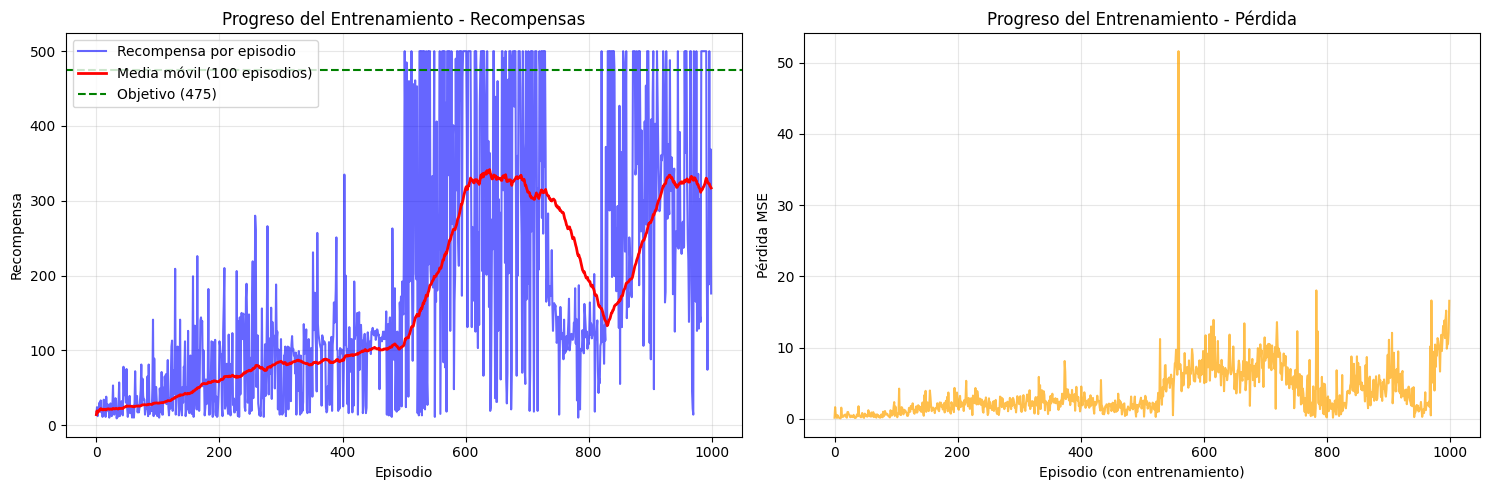

In [12]:
# Visualización de resultados
def plot_training_results(rewards, losses):
    """
    Visualiza los resultados del entrenamiento
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Gráfico de recompensas
    ax1.plot(rewards, alpha=0.6, color='blue', label='Recompensa por episodio')
    
    # Media móvil de 100 episodios
    if len(rewards) >= 100:
        moving_avg = [np.mean(rewards[max(0, i-100):i+1]) for i in range(len(rewards))]
        ax1.plot(moving_avg, color='red', linewidth=2, label='Media móvil (100 episodios)')
    
    ax1.axhline(y=475, color='green', linestyle='--', label='Objetivo (475)')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Recompensa')
    ax1.set_title('Progreso del Entrenamiento - Recompensas')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Gráfico de pérdidas
    valid_losses = [l for l in losses if l > 0]
    if valid_losses:
        ax2.plot(valid_losses, color='orange', alpha=0.7)
        ax2.set_xlabel('Episodio (con entrenamiento)')
        ax2.set_ylabel('Pérdida MSE')
        ax2.set_title('Progreso del Entrenamiento - Pérdida')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualizar resultados si el entrenamiento se ejecutó
if 'rewards' in locals() and 'losses' in locals():
    plot_training_results(rewards, losses)

### 10) Evaluación de rendimiento

In [14]:
def test_trained_agent(num_episodes=10, render=True):
    """
    Evalúa el rendimiento del agente entrenado
    
    Args:
        num_episodes: Número de episodios a probar
        render: Si mostrar la visualización del agente
    """
    print(f"Evaluando agente entrenado en {num_episodes} episodios...")
    
    # Crear entorno con o sin renderizado
    if render:
        test_env = gym.make("CartPole-v1", render_mode="human")
        print("Visualizando agente entrenado...")
    else:
        test_env = env
    
    total_rewards = []
    episode_lengths = []
    
    for episode in range(num_episodes):
        state, _ = test_env.reset()
        episode_reward = 0
        steps = 0
        
        while True:
            # Seleccionar acción sin exploración (epsilon = 0)
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = q_network(state_tensor)
                action = q_values.argmax().item()
            
            # Ejecutar acción
            state, reward, terminated, truncated, _ = test_env.step(action)
            episode_reward += reward
            steps += 1
            
            # Si el episodio terminó
            if terminated or truncated:
                total_rewards.append(episode_reward)
                episode_lengths.append(steps)
                print(f"Episodio {episode + 1:2d}: {steps:3d} pasos, Recompensa: {episode_reward:3.0f}")
                break
    
    # Cerrar entorno si se creó uno específico
    if render:
        test_env.close()
    
    # Calcular estadísticas
    avg_reward = np.mean(total_rewards)
    std_reward = np.std(total_rewards)
    max_reward = np.max(total_rewards)
    min_reward = np.min(total_rewards)
    avg_length = np.mean(episode_lengths)

    print(f"ESTADÍSTICAS DEL RENDIMIENTO:")
    print(f"{'='*50}")
    print(f"Recompensa promedio: {avg_reward:.2f} ± {std_reward:.2f}")
    print(f"Recompensa máxima:   {max_reward:.0f}")
    print(f"Recompensa mínima:   {min_reward:.0f}")
    print(f"Duración promedio:   {avg_length:.1f} pasos")
    print(f"{'='*50}")
    
    return total_rewards, episode_lengths

def compare_performance():
    """
    Compara el rendimiento del agente entrenado vs agente aleatorio
    """
    print("\n COMPARACIÓN DE RENDIMIENTO")
    print("="*60)
    
    # 1. Probar agente aleatorio
    print("1. Agente ALEATORIO (sin entrenamiento):")
    random_rewards = []
    for episode in range(10):
        state, _ = env.reset()
        episode_reward = 0
        steps = 0
        
        while True:
            action = env.action_space.sample()  # Acción aleatoria
            state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            steps += 1
            
            if terminated or truncated:
                random_rewards.append(episode_reward)
                print(f"  Episodio {episode + 1:2d}: {steps:3d} pasos, Recompensa: {episode_reward:3.0f}")
                break
    
    # 2. Probar agente entrenado
    print("\n2. Agente ENTRENADO:")
    trained_rewards = []
    for episode in range(10):
        state, _ = env.reset()
        episode_reward = 0
        steps = 0
        
        while True:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = q_network(state_tensor)
                action = q_values.argmax().item()
            
            state, reward, terminated, truncated, _ = env.step(action)
            episode_reward += reward
            steps += 1
            
            if terminated or truncated:
                trained_rewards.append(episode_reward)
                print(f"  Episodio {episode + 1:2d}: {steps:3d} pasos, Recompensa: {episode_reward:3.0f}")
                break
    
    # Comparar resultados
    random_avg = np.mean(random_rewards)
    trained_avg = np.mean(trained_rewards)
    improvement = trained_avg - random_avg
    improvement_pct = (improvement / random_avg) * 100 if random_avg > 0 else 0
    
    print(f"\n COMPARACIÓN:")
    print(f"Agente aleatorio: {random_avg:.1f} puntos promedio")
    print(f"Agente entrenado: {trained_avg:.1f} puntos promedio")
    print(f"Mejora: +{improvement:.1f} puntos ({improvement_pct:.1f}%)")
    
    return random_rewards, trained_rewards

def analyze_q_values():
    """
    Analiza los Q-values del agente entrenado en diferentes estados
    """
    print("\nANÁLISIS DE Q-VALUES")
    print("="*40)
    
    # Probar algunos estados específicos
    test_states = [
        [0.0, 0.0, 0.0, 0.0],      # Estado inicial perfecto
        [0.1, 0.5, 0.05, 0.1],     # Ligero desbalance
        [0.2, -0.3, -0.1, -0.5],   # Más desbalanceado
        [-0.15, 0.8, 0.15, 0.7],   # Muy desbalanceado
    ]
    
    state_names = [
        "Estado equilibrado",
        "Ligero desbalance", 
        "Desbalance moderado",
        "Muy desbalanceado"
    ]
    
    for i, (state, name) in enumerate(zip(test_states, state_names)):
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = q_network(state_tensor)
            action = q_values.argmax().item()
            
        print(f"{i+1}. {name}:")
        print(f"   Estado: {state}")
        print(f"   Q-values: Izquierda={q_values[0][0]:.3f}, Derecha={q_values[0][1]:.3f}")
        print(f"   Acción elegida: {'Izquierda' if action == 0 else 'Derecha'}")
        print()

# Ejecutar evaluaciones
print("EVALUACIÓN COMPLETA DEL AGENTE ENTRENADO")
print("="*60)

# 1. Evaluación sin visualización
print("1. Evaluación estadística (sin visualización):")
test_rewards, test_lengths = test_trained_agent(num_episodes=20, render=False)

# 2. Comparación con agente aleatorio
compare_performance()

# 3. Análisis de Q-values
analyze_q_values()

EVALUACIÓN COMPLETA DEL AGENTE ENTRENADO
1. Evaluación estadística (sin visualización):
Evaluando agente entrenado en 20 episodios...
Episodio  1: 500 pasos, Recompensa: 500
Episodio  2: 500 pasos, Recompensa: 500
Episodio  3: 500 pasos, Recompensa: 500
Episodio  4: 500 pasos, Recompensa: 500
Episodio  5: 500 pasos, Recompensa: 500
Episodio  6: 500 pasos, Recompensa: 500
Episodio  7: 500 pasos, Recompensa: 500
Episodio  8: 500 pasos, Recompensa: 500
Episodio  9: 500 pasos, Recompensa: 500
Episodio 10: 500 pasos, Recompensa: 500
Episodio 11: 500 pasos, Recompensa: 500
Episodio 12: 500 pasos, Recompensa: 500
Episodio 13: 500 pasos, Recompensa: 500
Episodio 14: 500 pasos, Recompensa: 500
Episodio 15: 500 pasos, Recompensa: 500
Episodio 16: 500 pasos, Recompensa: 500
Episodio 17: 500 pasos, Recompensa: 500
Episodio 18: 500 pasos, Recompensa: 500
Episodio 19: 500 pasos, Recompensa: 500
Episodio 20: 500 pasos, Recompensa: 500
ESTADÍSTICAS DEL RENDIMIENTO:
Recompensa promedio: 500.00 ± 0.00
R

### 11) Fine tuning